In [1]:
from graph_gen.gen_graph import gen_graph

# Basic Multi-agent Collaboration

A single agent can usually operate effectively using a handful of tools within a single domain, but even using powerful models like `gpt-4`, it can be less effective at using many tools. 

One way to approach complicated tasks is through a "divide-and-conquer" approach: create an specialized agent for each task or domain and route tasks to the correct "expert".

This notebook (inspired by the paper [AutoGen: Enabling Next-Gen LLM Applications via Multi-Agent Conversation](https://arxiv.org/abs/2308.08155), by Wu, et. al.) shows one way to do this using LangGraph.

The resulting graph will look something like the following diagram:

![multi_agent diagram](../img/simple_multi_agent_diagram.png)

Before we get started, a quick note: this and other multi-agent notebooks are designed to show _how_ you can implement certain design patterns in LangGraph. If the pattern suits your needs, we recommend combining it with some of the other fundamental patterns described elsewhere in the docs for best performance.

In [1]:
%%capture --no-stderr
%pip install -U langchain langchain_openai langsmith pandas langchain_experimental matplotlib langgraph langchain_core

In [2]:
import getpass
import os


def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"Please provide your {var}")


_set_if_undefined("OPENAI_API_KEY")
_set_if_undefined("LANGSMITH_API_KEY")
_set_if_undefined("TAVILY_API_KEY")

# Optional, add tracing in LangSmith
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Multi-agent Collaboration"

## Create Agents

The following helper functions will help create agents. These agents will then be nodes in the graph.

You can skip ahead if you just want to see what the graph looks like.

In [3]:
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    ToolMessage,
)
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

from langgraph.graph import END, StateGraph, START


def create_agent(llm, tools, system_message: str):
    """Create an agent."""
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI assistant, collaborating with other assistants."
                " Use the provided tools to progress towards answering the question."
                " If you are unable to fully answer, that's OK, another assistant with different tools "
                " will help where you left off. Execute what you can to make progress."
                " If you or any of the other assistants have the final answer or deliverable,"
                " prefix your response with FINAL ANSWER so the team knows to stop."
                " You have access to the following tools: {tool_names}.\n{system_message}",
            ),
            MessagesPlaceholder(variable_name="messages"),
        ]
    )
    prompt = prompt.partial(system_message=system_message)
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
    return prompt | llm.bind_tools(tools)

## Define tools

We will also define some tools that our agents will use in the future

In [4]:
from typing import Annotated

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

tavily_tool = TavilySearchResults(max_results=5)

# Warning: This executes code locally, which can be unsafe when not sandboxed

repl = PythonREPL()


@tool
def python_repl(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

## Create graph

Now that we've defined our tools and made some helper functions, will create the individual agents below and tell them how to talk to each other using LangGraph.

### Define State

We first define the state of the graph. This will just a list of messages, along with a key to track the most recent sender

In [5]:
import operator
from typing import Annotated, Sequence, TypedDict

from langchain_openai import ChatOpenAI


# This defines the object that is passed between each node
# in the graph. We will create different nodes for each agent and tool
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    sender: str

### Define Agent Nodes

We now need to define the nodes. First, let's define the nodes for the agents.

In [6]:
import functools

from langchain_core.messages import AIMessage


# Helper function to create a node for a given agent
def agent_node(state, agent, name):
    print(f"AGENT_NODE: {name}")
    result = agent.invoke(state)
    # We convert the agent output into a format that is suitable to append to the global state
    if isinstance(result, ToolMessage):
        pass
    else:
        print(f"BEFORE {name}", result)
        result = AIMessage(**result.dict(exclude={"name"}), name=name)
        print(f"AFTER {name}", result)
    return {
        "messages": [result],
        # Since we have a strict workflow, we can
        # track the sender so we know who to pass to next.
        "sender": name,
    }


llm = ChatOpenAI(model="gpt-4-1106-preview")

# Research agent and node
research_agent = create_agent(
    llm,
    [tavily_tool],
    system_message="You should provide accurate data for the chart_generator to use.",
)
research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")

# chart_generator
chart_agent = create_agent(
    llm,
    [python_repl],
    system_message="Any charts you display will be visible by the user.",
)
chart_node = functools.partial(agent_node, agent=chart_agent, name="chart_generator")

### Define Tool Node

We now define a node to run the tools

In [7]:
from langgraph.prebuilt import ToolNode

tools = [tavily_tool, python_repl]
tool_node = ToolNode(tools)

### Define Edge Logic

We can define some of the edge logic that is needed to decide what to do based on results of the agents

In [8]:
# Either agent can decide to end
from typing import Literal

def router(state) -> Literal["call_tool", "__end__", "continue"]:
    # This is the router
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        # The previous agent is invoking a tool
        return "call_tool"
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return "__end__"
    return "continue"

def last_is_tool_message(state) -> bool:
    return state["messages"][-1].tool_calls

def got_final_answer(state) -> bool:
    return "FINAL ANSWER" in state["messages"][-1].content

def called_from_researcher(state) -> bool:
    return state["sender"] == "Researcher"

### Define the Graph

We can now put it all together and define the graph!

In [9]:
workflow = StateGraph(AgentState)

workflow.add_node("Researcher", research_node)
workflow.add_node("chart_generator", chart_node)
workflow.add_node("call_tool", tool_node)

workflow.add_conditional_edges(
    "Researcher",
    router,
    {"continue": "chart_generator", "call_tool": "call_tool", "__end__": END},
)
workflow.add_conditional_edges(
    "chart_generator",
    router,
    {"continue": "Researcher", "call_tool": "call_tool", "__end__": END},
)

workflow.add_conditional_edges(
    "call_tool",
    # Each agent node updates the 'sender' field
    # the tool calling node does not, meaning
    # this edge will route back to the original agent
    # who invoked the tool
    lambda x: x["sender"],
    {
        "Researcher": "Researcher",
        "chart_generator": "chart_generator",
    },
)
workflow.add_edge(START, "Researcher")
graph = workflow.compile()

In [11]:
graph_spec = """
research_node(AgentState)
   last_is_tool_message => tool_node
   got_final_answer => END
   => chart_node

tool_node
   called_from_researcher => research_node
   got_final_answer => END
   => chart_node

chart_node
   last_is_tool_message => tool_node
   got_final_answer => END
   => research_node
"""
graph_code = gen_graph("multi_agent", graph_spec)
print(graph_code)
exec(graph_code)

multi_agent = StateGraph(AgentState)
multi_agent.add_node('research_node', research_node)
multi_agent.add_node('tool_node', tool_node)
multi_agent.add_node('chart_node', chart_node)

multi_agent.set_entry_point('research_node')

def after_research_node(state: AgentState):
    if last_is_tool_message(state):
        return 'tool_node'
    elif got_final_answer(state):
        return 'END'
    return 'chart_node'

research_node_dict = {'tool_node': 'tool_node', 'END': END, 'chart_node': 'chart_node'}
multi_agent.add_conditional_edges('research_node', after_research_node, research_node_dict)

def after_tool_node(state: AgentState):
    if called_from_researcher(state):
        return 'research_node'
    elif got_final_answer(state):
        return 'END'
    return 'chart_node'

tool_node_dict = {'research_node': 'research_node', 'END': END, 'chart_node': 'chart_node'}
multi_agent.add_conditional_edges('tool_node', after_tool_node, tool_node_dict)

def after_chart_node(state: AgentState):


In [10]:
multi_agent

CompiledStateGraph(nodes={'__start__': PregelNode(config={'tags': ['langsmith:hidden'], 'metadata': {}}, channels=['__start__'], triggers=['__start__'], writers=[ChannelWrite<messages,sender>(recurse=True, writes=[ChannelWriteEntry(channel='messages', value=<object object at 0x10f65a310>, skip_none=False, mapper=_get_state_key(recurse=False)), ChannelWriteEntry(channel='sender', value=<object object at 0x10f65a310>, skip_none=False, mapper=_get_state_key(recurse=False))], require_at_least_one_of=['messages', 'sender']), ChannelWrite<start:research_node>(recurse=True, writes=[ChannelWriteEntry(channel='start:research_node', value='__start__', skip_none=False, mapper=None)], require_at_least_one_of=None)]), 'research_node': PregelNode(config={'tags': [], 'metadata': {}}, channels={'messages': 'messages', 'sender': 'sender'}, triggers=['start:research_node', 'branch:tool_node:after_tool_node:research_node', 'branch:chart_node:after_chart_node:research_node'], mapper=functools.partial(<fun

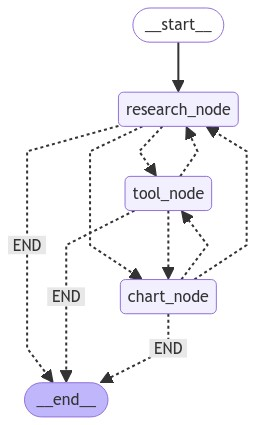

In [12]:
from IPython.display import Image, display

try:
    display(Image(multi_agent.get_graph(xray=True).draw_mermaid_png()))
    #display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

## Invoke

With the graph created, you can invoke it! Let's have it chart some stats for us.

AGENT_NODE: Researcher
BEFORE Researcher content='' additional_kwargs={'tool_calls': [{'id': 'call_AbkQ5t1XtWFMrS3SoLsaUp8P', 'function': {'arguments': '{"query":"UK GDP by year for the past 5 years"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 221, 'total_tokens': 248}, 'model_name': 'gpt-4-1106-preview', 'system_fingerprint': None, 'finish_reason': 'tool_calls', 'logprobs': None} id='run-dc1ccc80-6f39-49aa-b703-c15480b852d1-0' tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'UK GDP by year for the past 5 years'}, 'id': 'call_AbkQ5t1XtWFMrS3SoLsaUp8P', 'type': 'tool_call'}] usage_metadata={'input_tokens': 221, 'output_tokens': 27, 'total_tokens': 248}
AFTER Researcher content='' additional_kwargs={'tool_calls': [{'id': 'call_AbkQ5t1XtWFMrS3SoLsaUp8P', 'function': {'arguments': '{"query":"UK GDP by year for the past 5 years"}', 'name': 'tavily_search_results_json'}, 'typ

Python REPL can execute arbitrary code. Use with caution.


BEFORE chart_generator content='' additional_kwargs={'tool_calls': [{'id': 'call_NKxpI1nPpN6PVWD1DtLLeivS', 'function': {'arguments': '{"code":"import matplotlib.pyplot as plt\\n\\n# UK\'s GDP over the past 5 years in billions\\nyears = [\'2017\', \'2018\', \'2019\', \'2020\', \'2021\']\\ngdp_values = [3047.35, 3059.24, 2851.41, 2697.81, 3141.51]\\n\\n# Create a line graph\\nplt.figure(figsize=(10, 5))\\nplt.plot(years, gdp_values, marker=\'o\')\\nplt.title(\'UK GDP Over the Past 5 Years\')\\nplt.xlabel(\'Year\')\\nplt.ylabel(\'GDP in Billions USD\')\\nplt.grid(True)\\nplt.tight_layout()\\nplt.show()"}', 'name': 'python_repl'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 171, 'prompt_tokens': 1337, 'total_tokens': 1508}, 'model_name': 'gpt-4-1106-preview', 'system_fingerprint': None, 'finish_reason': 'tool_calls', 'logprobs': None} id='run-6dff688c-3e4e-405a-8982-dbeb4486f6ca-0' tool_calls=[{'name': 'python_repl', 'args': {'code': "import matplotlib.py

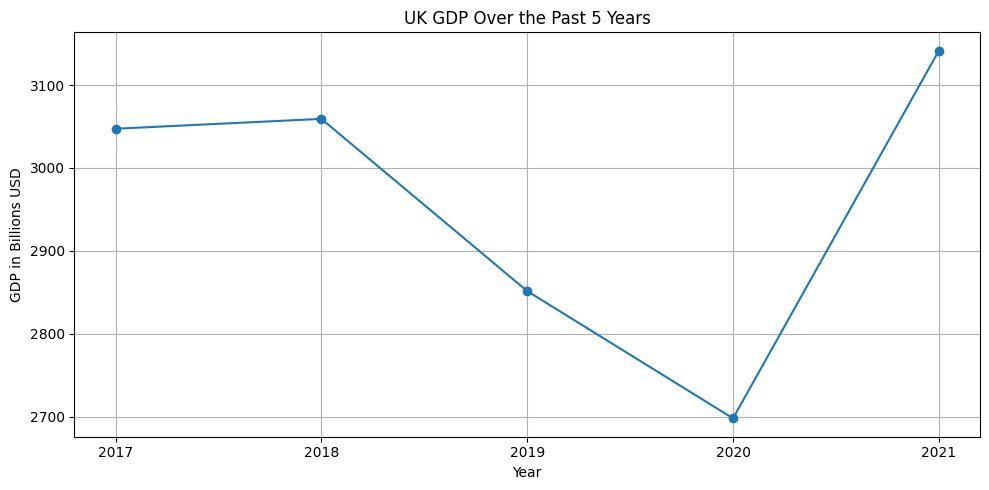

{'tool_node': {'messages': [ToolMessage(content="Successfully executed:\n```python\nimport matplotlib.pyplot as plt\n\n# UK's GDP over the past 5 years in billions\nyears = ['2017', '2018', '2019', '2020', '2021']\ngdp_values = [3047.35, 3059.24, 2851.41, 2697.81, 3141.51]\n\n# Create a line graph\nplt.figure(figsize=(10, 5))\nplt.plot(years, gdp_values, marker='o')\nplt.title('UK GDP Over the Past 5 Years')\nplt.xlabel('Year')\nplt.ylabel('GDP in Billions USD')\nplt.grid(True)\nplt.tight_layout()\nplt.show()\n```\nStdout: \n\nIf you have completed all tasks, respond with FINAL ANSWER.", name='python_repl', tool_call_id='call_NKxpI1nPpN6PVWD1DtLLeivS')]}}
----


In [13]:
events = multi_agent.stream(
    {
        "messages": [
            HumanMessage(
                content="Fetch the UK's GDP over the past 5 years,"
                " then draw a line graph of it."
                " Once you code it up, finish."
            )
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 150},
)
for s in events:
    print(s)
    print("----")

I am working on a RAG chatbot application where we will first to have if either the given question is having enough knowledge to be answered or we need some further information before answering. Or if a question is a general question which doesn't even need RAG search. For example, if a question is "What are the main components of a car?" then we don't need RAG search but if a question is "What type of suspensions do you have for a car?" then we will do RAG search.

Till now, I created a simple ReACT agent in langchain to ask the followup questions with a tool and now I need to integrate if the given query is something that can be answered without any tool or not and for this, I am thinking about first having an agent which qualifies the given query and if its qualified for RAG search then second agent will do either RAG search or follow-up questions.



In [16]:
# State
class RagState(TypedDict):
    user_input: str
    do_rag: bool
    search_result: str

# Nodes -- change state (return state updates)
def route_question(state):
    # check state
    return { "do_rag": True }

def rag_search(state):
    # do rag search
    return { "result": "something" }

def web_search(state):
    # do web search
    return { "result": "something" }

# Edge Conditions -- bool functions
def is_rag(state):
    return state["do_rag"]
    
graph_spec = """
route_question(RagState)
  is_rag => rag_search
  => web_search

rag_search
  => END

web_search
  => END
"""
# route_question, rag_search, web_search all take State as a parameter, and return updates to that State
# is_rag takes State parameter and returns a boolean

# So you only need to consider these functions, and the graph specification above
graph_code = gen_graph("rag_graph", graph_spec)
print(graph_code)
exec(graph_code)

rag_graph = StateGraph(RagState)
rag_graph.add_node('route_question', route_question)
rag_graph.add_node('rag_search', rag_search)
rag_graph.add_node('web_search', web_search)

rag_graph.set_entry_point('route_question')

def after_route_question(state: RagState):
    if is_rag(state):
        return 'rag_search'
    return 'web_search'

route_question_dict = {'rag_search': 'rag_search', 'web_search': 'web_search'}
rag_graph.add_conditional_edges('route_question', after_route_question, route_question_dict)

rag_graph.add_edge('rag_search', END)
rag_graph.add_edge('web_search', END)

rag_graph = rag_graph.compile()
